In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

g = 9.805
mpl.rc('font',family='Times New Roman')

In [2]:
def Gamma(D1):
    s = 0
    ss = 0
    for i in range(len(D1)):
        s = D1[i]*m[i] + s
        ss = D1[i]**2*m[i] + ss
    return s/ss, s**2/ss

In [3]:
m = [0, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0, 0.363, 
     0.363, 0.363, 0.363, 0.363, 0.363, 0]

In [4]:
im = 9

In [5]:
model = 'M02_biron'

In [6]:
dispX = np.loadtxt(model+"_DispX.txt")
dispY = np.loadtxt(model+"_DispY.txt")

In [7]:
Dxm = np.zeros(10)
Dym = np.zeros(10)

for i in range(len(Dxm)):
    dx = dispX[:,i]
    dx = dx[dx != 0]
    Dxm[i] = np.median(dx)
    
    dy = dy = dispY[:,i]
    dy = dy[dy != 0]
    Dym[i] = np.median(dy)

In [8]:
data = np.load("M02_peak_displacements.npy", allow_pickle=True).item()

dispXs = data["dispXs"]
dispYs = data["dispYs"]

In [9]:
DxmS = np.zeros(10)
DymS = np.zeros(10)

for i in range(10):
    DxmS[i] = np.median(dispXs[:,i])
    DymS[i] = np.median(dispYs[:,i])


Text(0, 0.5, 'Peak Suspended Piping Displacement')

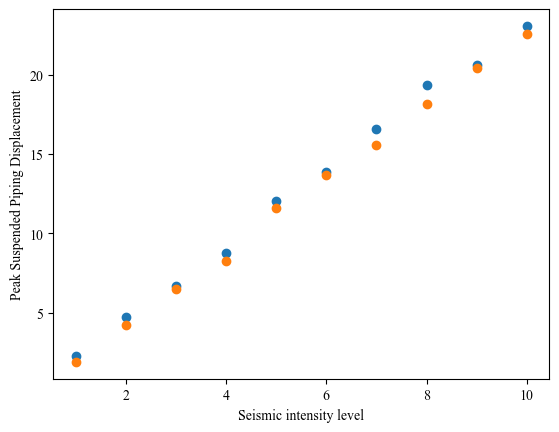

In [12]:
im = [1,2,3,4,5,6,7,8,9,10]
#plt.scatter(im,Dxm)
plt.scatter(im,Dym)
plt.scatter(im,DymS*0.825*1.21)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'Peak Suspended Piping Displacement')

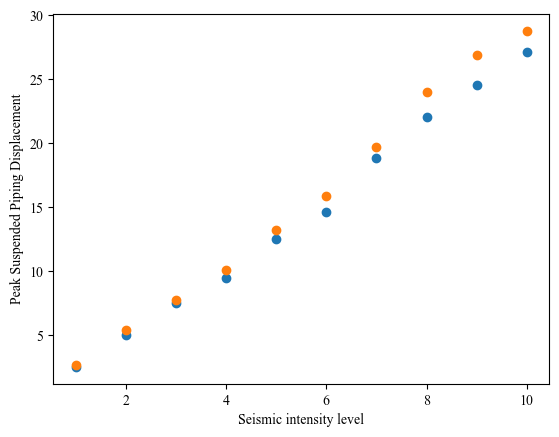

In [13]:
plt.scatter(im,Dxm)
plt.scatter(im,DxmS*1.05*1.0)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'MRE')

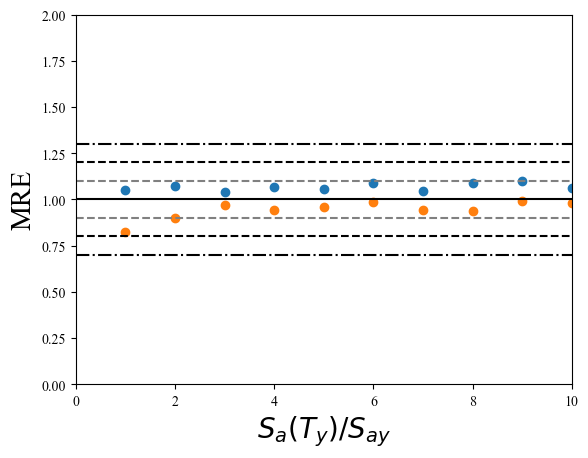

In [14]:
plt.scatter(im,DxmS*1.05*1.0/Dxm)
plt.scatter(im,DymS*0.825*1.21/Dym)

plt.plot((0,10),(1.1,1.1),color='grey',ls='--')
plt.plot((0,10),(0.9,0.9),color='grey',ls='--')

plt.plot((0,10),(1.2,1.2),color='k',ls='--')
plt.plot((0,10),(0.8,0.8),color='k',ls='--')

plt.plot((0,10),(1.3,1.3),color='k',ls='-.')
plt.plot((0,10),(0.7,0.7),color='k',ls='-.')

plt.plot((0,10),(1,1),color='k')
plt.ylim(0,2)
plt.xlim(0,10)
plt.xlabel(r'$S_{a}(T_y)/S_{ay}$',fontsize=20)
plt.ylabel(r'MRE',fontsize=20)

In [15]:
DispShapeX = np.load(model+"DispShapeX.npy")
DispShapeY = np.load(model+"DispShapeY.npy")

In [16]:
def DispShapeStat(DispShapeX,DispShapeY):
    tol = 0
    mask_rowsX = np.any(DispShapeX > tol, axis=(1))
    mask_rowsY = np.any(DispShapeY > tol, axis=(1))
    
    DispShapeX_no_zero = DispShapeX[mask_rowsX, :]
    DispShapeY_no_zero = DispShapeY[mask_rowsY, :]
    
    DSXm = DispShapeX_no_zero.mean(axis=0)
    DSYm = DispShapeY_no_zero.mean(axis=0)
    
    DSXs = DispShapeX_no_zero.std(axis=0)
    DSYs = DispShapeY_no_zero.std(axis=0)

    return DSXm,DSYm,DSXs,DSYs

In [17]:
DSXm = np.zeros((21,10))
DSYm = np.zeros((21,10))

DSXs = np.zeros((21,10))
DSYs = np.zeros((21,10))

for i in range(10):
    DSXm[:,i],DSYm[:,i],DSXs[:,i],DSYs[:,i] = DispShapeStat(DispShapeX[:,:,i],DispShapeY[:,:,i])

In [18]:

POy = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M02y.txt')
POx = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M02x.txt')

In [19]:
Vbx_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM02x_SDOF/VbaseC.out')
Dx_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM02x_SDOF/DispC.out')

In [20]:
Vby_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM02y_SDOF/VbaseC.out')
Dy_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM02y_SDOF/DispC.out')

In [21]:
Fx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM02_biron/ReactionsX.out')

Vbx_3D = np.zeros(len(Fx_3D[:,0]))
for i in range(len(Vbx_3D)):
    Vbx_3D[i] = -1*np.sum(Fx_3D[i,1:])

Dx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM02_biron/PipeNodeDispX.out')

Dx3D_eq = np.zeros(len(Dx_3D[:,0]))
for i in range(len(Dx3D_eq)):
    Dx3D_eq[i] = np.sum(Dx_3D[i,1:]**2)/np.sum(Dx_3D[i,1:])


In [22]:
Fy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM02_biron/ReactionsY.out')

Vby_3D = np.zeros(len(Fy_3D[:,0]))
for i in range(len(Vby_3D)):
    Vby_3D[i] = -1*np.sum(Fy_3D[i,1:])

Dy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM02_biron/PipeNodeDispY.out')

Dy3D_eq = np.zeros(len(Dy_3D[:,0]))
for i in range(len(Dy3D_eq)):
    Dy3D_eq[i] = np.sum(Dy_3D[i,1:]**2)/np.sum(Dy_3D[i,1:])


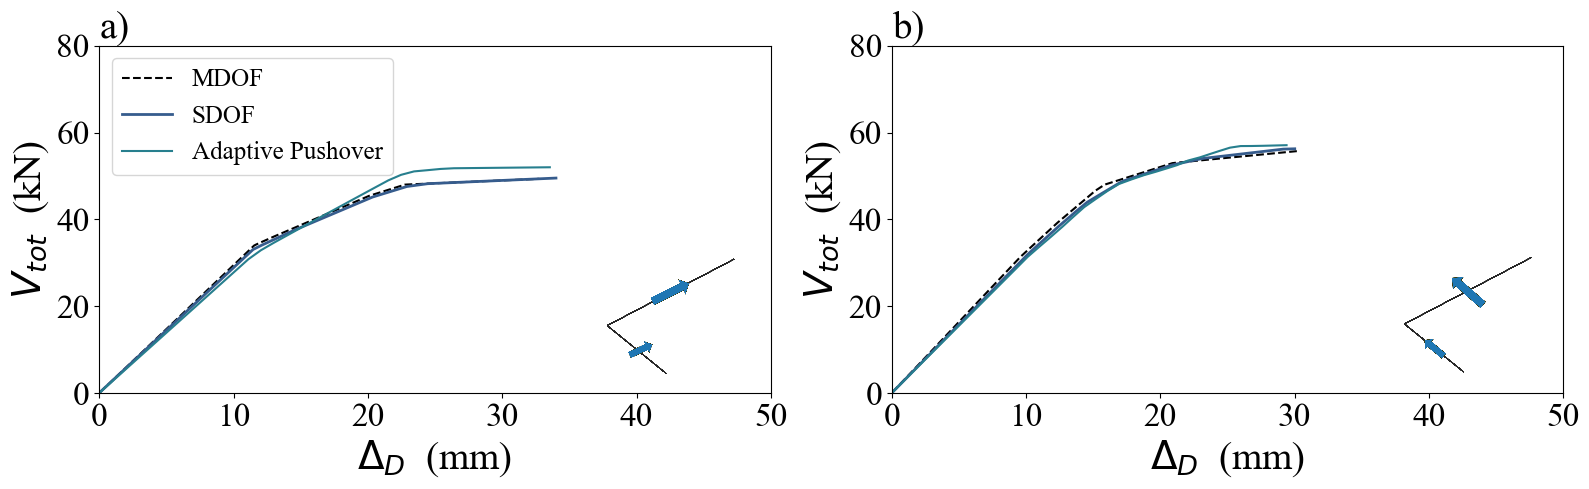

In [23]:
fig, ax = plt.subplots(ncols = 2, nrows=1,figsize=(16, 5))

ax[0].text(0,82,'a)',fontsize=28)
ax[0].plot(Dx3D_eq[:680],Vbx_3D[:680]/1000,color='k',label='MDOF',ls='--')
ax[0].plot(Dx_SDOF[:680],Vbx_SDOF[:680]/1000, label='SDOF',color='#365c8d',lw=2)
ax[0].plot(POx[:36,5],POx[:36,3]/1000,label='Adaptive Pushover',color='#277f8e')


im = mpimg.imread('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/subFigure1.tiff')
imagebox = OffsetImage(im, zoom = 0.06)

ab = AnnotationBbox(imagebox, (1, 0.42), xycoords='axes fraction', box_alignment=(1.1, 1), frameon = False)
ax[0].add_artist(ab)

ax[0].set_xlim(0,50)
ax[0].set_ylim(0,80)
ax[0].tick_params(labelsize=24)
ax[0].set_xlabel(r'$\Delta_{D}$  (mm)',fontsize=28)
ax[0].set_ylabel(r'$V_{tot}$  (kN)',fontsize=28)
ax[0].legend(fontsize=18)

ax[1].text(0,82,'b)',fontsize=28)
ax[1].plot(Dy3D_eq[:680],Vby_3D[:680]/1000,color='k',label='MDOF',ls='--')
ax[1].plot(Dy_SDOF[:600],Vby_SDOF[:600]/1000, label='SDOF',color='#365c8d',lw=2)
ax[1].plot(POy[:36,5],POy[:36,3]/1000,label='Adaptive Pushover',color='#277f8e')

im2 = mpimg.imread('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/subFigure2.tiff')
imagebox2 = OffsetImage(im2, zoom = 0.06)

ab2 = AnnotationBbox(imagebox2, (1, 0.42), xycoords='axes fraction', box_alignment=(1.1, 1), frameon = False)
ax[1].add_artist(ab2)

ax[1].set_xlim(0,50)
ax[1].set_ylim(0,80)
ax[1].tick_params(labelsize=24)
ax[1].set_xlabel(r'$\Delta_{D}$  (mm)',fontsize=28)
ax[1].set_ylabel(r'$V_{tot}$  (kN)',fontsize=28)
#ax[1].legend(fontsize=18,loc=1)

plt.tight_layout()
plt.savefig('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/Figure11.tiff',dpi=300)

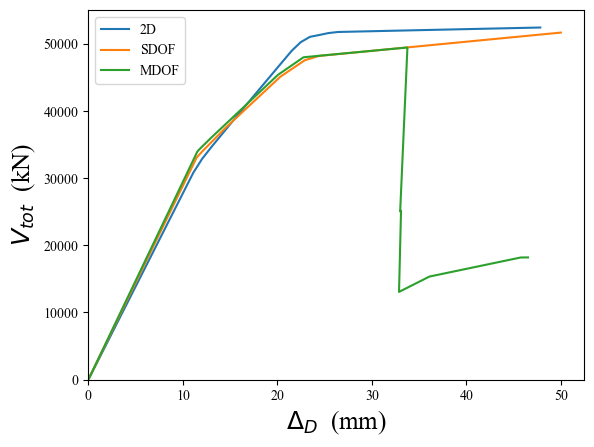

In [24]:
plt.plot(POx[:,5],POx[:,3],label='2D')
plt.plot(Dx_SDOF,Vbx_SDOF,label='SDOF')
plt.plot(Dx3D_eq,Vbx_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

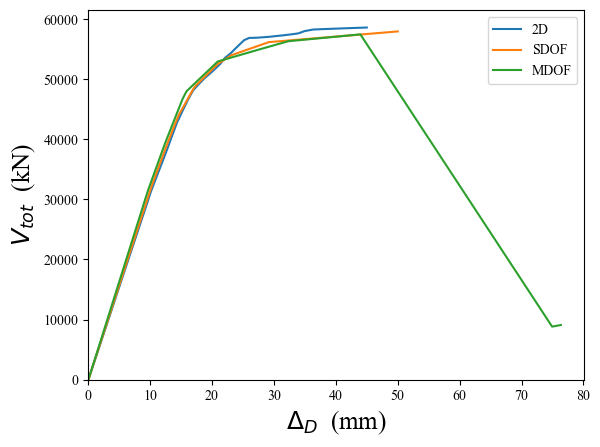

In [25]:
plt.plot(POy[:,5],POy[:,3],label='2D')
plt.plot(Dy_SDOF,Vby_SDOF,label='SDOF')
plt.plot(Dy3D_eq,Vby_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

In [26]:
Dstaticx = POx[:,6:13]
Dstaticx = np.flip(Dstaticx)

In [27]:
im =8

In [30]:
Dstaticy = POy[:,6:19]
Dt = np.array([1.1, 1.7, 1.68,1])

In [32]:
x0 = np.zeros(21)
y0 = np.zeros(21)

x0[1] = 1

for i in range(2,len(x0)):
    if(i<13):
        x0[i] = 3*(i-1)+x0[1]
    else:
        x0[i] = 36

y0[14] = 1        
for i in range(15,20):
    y0[i] = y0[14]+3*(i-14)

y0[20] = 18

In [33]:
dsdx = np.ones(len(x0))
print(x0[14:])
dsdx[14:] = np.multiply(dsdx[14:],Dstaticx[20,:])

[36. 36. 36. 36. 36. 36. 36.]


In [34]:
np.mean(abs(dsdx-DSXm[:,im])/DSXm[:,im])*100

3.5379107359292616

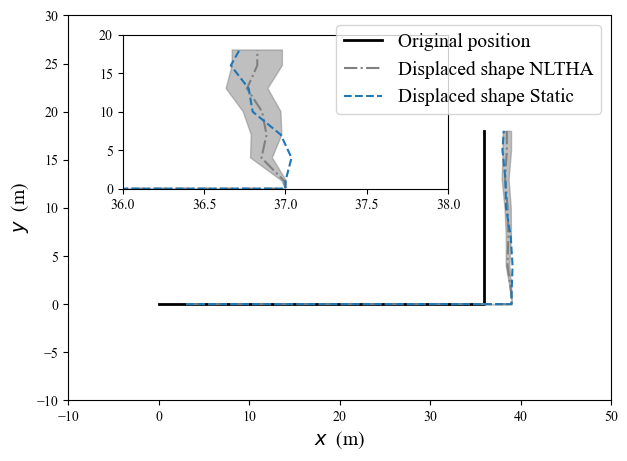

In [35]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0,y0, color='k',lw=2,label='Original position')
ax.plot(x0+3*DSXm[:,im],y0, color='grey',ls='-.',label='Displaced shape NLTHA')
ax.fill_betweenx(y0,x0+3*(DSXm[:,im]+2*DSXs[:,im]),x0+3*(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.5)
ax.plot(x0+3*dsdx,y0, color='C0',ls='--',label='Displaced shape Static')
axins1 = ax.inset_axes([0.1, 0.55, 0.6, 0.4],xlim=(36,38), ylim=(0, 20))
axins1.plot(x0+DSXm[:,im],y0, color='grey',ls='-.',label='Displaced shape NLTHA')
axins1.fill_betweenx(y0,x0+(DSXm[:,im]+2*DSXs[:,im]),x0+(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.5)
axins1.plot(x0+dsdx,y0, color='C0',ls='--',label='Displaced shape Static')
#plt.plot(x0+3*np.ones(len(x0)),y0, color='C0',ls='--',label='Displaced shape Static')


ax.set_xlim(-10,50)
ax.set_ylim(-10,30)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=14)

In [36]:
Gx_NLTH, mx_NLTH = Gamma(DSXm[:,5])
Gx_NLTH

1.0332599660155253

In [37]:
mx_NLTH/np.sum(m)

0.9957050006740282

In [38]:
np.sum(m)

6.533999999999999

In [39]:
mx_NLTH

6.505936474404099

In [40]:
Gx_static = POx[20,1]
Gx_static

1.047

In [41]:
mx_static_mod = POx[10,4]
mx_static_mod

0.984

In [42]:
mx_static = POx[20,2]
mx_static

6.559

In [43]:
POx[20,4]

0.983

In [44]:
abs(Gx_static-Gx_NLTH)/Gx_NLTH

0.01329775123046643

In [45]:
Dstaticx[20,:]

array([1.   , 1.037, 0.971, 0.798, 0.774, 0.664, 0.717])

In [46]:
dsdy = np.ones(len(y0))
print(y0[:14])
ix = 9
dsdy[:14] = np.multiply(dsdy[:14],np.append(Dstaticy[ix,0],Dstaticy[ix,:]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [47]:
np.mean(abs(dsdy-DSYm[:,im])/DSYm[:,im])*100

6.013716020962876

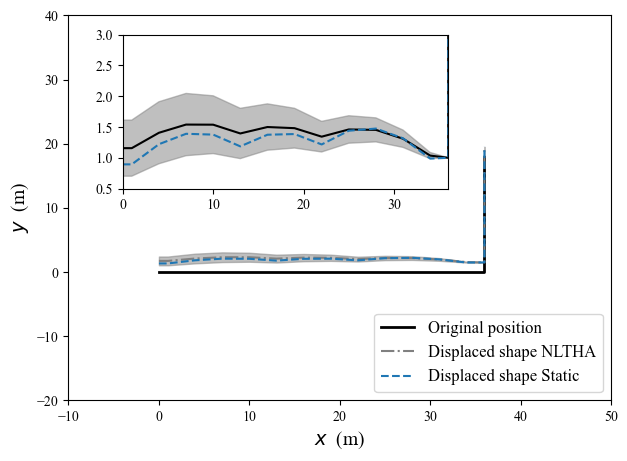

In [48]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0,y0, color='k',lw=2,label='Original position')
ax.plot(x0,y0+1.5*DSYm[:,im], color='grey',ls='-.',label='Displaced shape NLTHA')
ax.plot(x0,y0+1.5*dsdy, color='C0',ls='--',label='Displaced shape Static')
ax.fill_between(x0,y0+1.5*(DSYm[:,im]+2*DSYs[:,im]),y0+1.5*(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
axins1 = ax.inset_axes([0.1, 0.55, 0.6, 0.4],xlim=(0,36), ylim=(0.5, 3))
axins1.plot(x0,y0+DSYm[:,im],color='k')
axins1.fill_between(x0,y0+(DSYm[:,im]+2*DSYs[:,im]),y0+(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
axins1.plot(x0,y0+dsdy, color='C0',ls='--',label='Displaced shape Static')
#ax.indicate_inset_zoom(axins1, edgecolor="black")

ax.set_xlim(-10,50)
ax.set_ylim(-20,40)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)
#plt.xlim(-5,40)
#plt.ylim(0,4)
plt.legend(fontsize=12,loc=4)

In [49]:
Gy_NLTH, my_NLTH = Gamma(DSYm[:,5])
Gy_NLTH

0.7678788980725109

In [50]:
modal_my_NLTH = my_NLTH/np.sum(m)

In [51]:
np.sum(m)

6.533999999999999

In [52]:
my_NLTH

6.329264474618623

In [53]:
Gy_static = POy[10,1]
Gy_static

0.825

In [54]:
my_static = POy[10,2]
my_static

6.513

In [55]:
modal_my_static = POy[-1,4]

In [71]:
modal_my_static*np.sum(m)

6.5013299999999985

In [72]:
abs(Gy_static-Gy_NLTH)/Gy_NLTH

0.07438816468439421

In [73]:
abs(modal_my_NLTH-modal_my_static)/my_NLTH

0.0041606529452310175

In [74]:
Dstaticy[10,:]

array([0.894, 1.221, 1.39 , 1.377, 1.186, 1.375, 1.386, 1.217, 1.44 ,
       1.475, 1.317, 0.988, 1.   ])

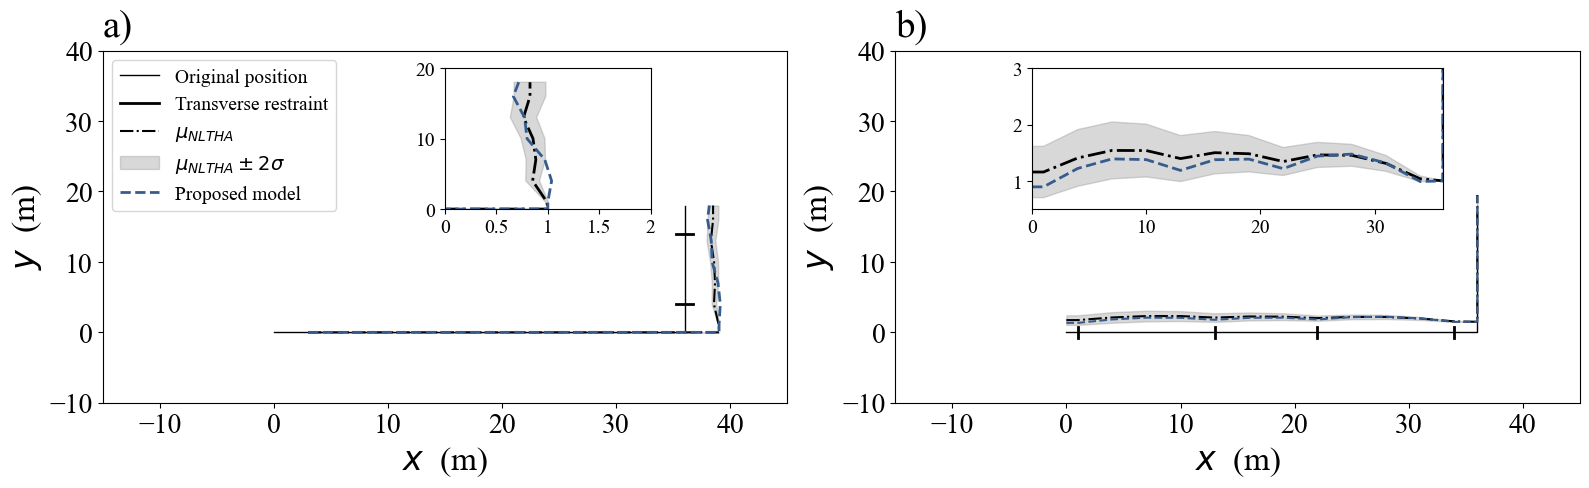

In [76]:
fig, ax = plt.subplots(ncols=2,figsize=(16,5))

ax[0].plot(x0,y0, color='k',lw=1,label='Original position')
ax[0].plot((35.25,36.75),(4,4),color='k',lw=2,label='Transverse restraint')
ax[0].plot(x0+3*DSXm[:,im],y0, color='k',ls='-.',label=r'$\mu_{NLTHA}$')
ax[0].fill_betweenx(y0,x0+3*(DSXm[:,im]+2*DSXs[:,im]),x0+3*(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.3,label=r'$\mu_{NLTHA} \pm 2\sigma$')
ax[0].plot(x0+3*dsdx,y0, color='#365c8d',ls='--',lw=2,label='Proposed model')
ax[0].plot((35.25,36.75),(14,14),color='k',lw=2)
axins1 = ax[0].inset_axes([0.5, 0.55, 0.3, 0.4],xlim=(36,38), ylim=(0, 20))
axins1.plot(x0+DSXm[:,im],y0, color='k',ls='-.',lw=2)
axins1.fill_betweenx(y0,x0+(DSXm[:,im]+2*DSXs[:,im]),x0+(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.3)
axins1.plot(x0+dsdx,y0, color='#365c8d',ls='--',lw=2,label='Displaced shape Static')
axins1.set_xticks(ticks=[36,36.5,37,37.5,38],labels=[0,0.5,1,1.5,2])
axins1.tick_params(labelsize=14)
ax[0].text(-15,42,'a)',fontsize=28)
ax[0].set_xlim(-15,45)
ax[0].set_ylim(-10,40)
ax[0].tick_params(labelsize=20)
ax[0].set_ylabel(r'$y$  (m)',fontsize=24)
ax[0].set_xlabel(r'$x$  (m)',fontsize=24)
ax[0].legend(fontsize=14,loc=2)


ax[1].plot(x0,y0, color='k',lw=1,label='Original position')
ax[1].plot(x0,y0+1.5*DSYm[:,im], color='k',ls='-.',label='NLTHA')
ax[1].plot(x0,y0+1.5*dsdy, color='#365c8d',ls='--',label='Proposed model')
ax[1].fill_between(x0,y0+1.5*(DSYm[:,im]+2*DSYs[:,im]),y0+1.5*(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.3)
ax[1].plot((1,1),(-0.75,0.75),color='k',lw=2)
ax[1].plot((13,13),(-0.75,0.75),color='k',lw=2)
ax[1].plot((22,22),(-0.75,0.75),color='k',lw=2)
ax[1].plot((34,34),(-0.75,0.75),color='k',lw=2)
ax[1].text(-15,42,'b)',fontsize=28)
axins2 = ax[1].inset_axes([0.2, 0.55, 0.6, 0.4],xlim=(0,36), ylim=(0.5, 3))
axins2.plot(x0,y0+DSYm[:,im],color='k',ls='-.',lw=2)
axins2.fill_between(x0,y0+(DSYm[:,im]+2*DSYs[:,im]),y0+(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.3)
axins2.plot(x0,y0+dsdy, color='#365c8d',ls='--',lw=2,label='Displaced shape Static')
axins2.tick_params(labelsize=14)

ax[1].set_xlim(-15,45)
ax[1].set_ylim(-10,40)
ax[1].set_ylabel(r'$y$  (m)',fontsize=24)
ax[1].set_xlabel(r'$x$  (m)',fontsize=24)
ax[1].tick_params(labelsize=20)
#plt.xlim(-5,40)
#plt.ylim(0,4)
#ax[1].legend(fontsize=16,loc=4)

plt.tight_layout()
#plt.savefig('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/Figure9.tiff',dpi=300)